<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [81]:
data = pd.DataFrame({
    "Review": [
        "Amazing movie with excellent acting",
        "Worst movie ever",
        "The story was average",
        "Fantastic direction and music",
        "I hated this movie",
        "Brilliant screenplay and performances",
        "Not bad but could be better",
        "Terrible acting and boring plot",
        "Excellent visuals and great songs",
        "Waste of time",
        "Loved every scene",
        "The ending was disappointing",
        "Average movie with decent acting",
        "Highly recommended",
        "Poor screenplay and weak acting",
        "Superb action sequences",
        "Movie was okay",
        "Absolutely fantastic experience",
        "Very boring movie",
        "Good family entertainer",
        "The acting was outstanding",
        "The plot was confusing",
        "An enjoyable movie with emotional scenes",
        "Nothing special about this film",
        "The comedy scenes were hilarious",
        "The movie was too lengthy",
        "Excellent cinematography",
        "Disappointing climax",
        "A perfect blend of action and drama",
        "Just an average one-time watch"
    ],

    "Sentiment": [
        "Positive","Negative","Neutral","Positive","Negative",
        "Positive","Neutral","Negative","Positive","Negative",
        "Positive","Negative","Neutral","Positive","Negative",
        "Positive","Neutral","Positive","Negative","Positive",
        "Positive","Neutral","Positive","Neutral","Positive",
        "Negative","Positive","Negative","Positive","Neutral"
    ]
})

data.head()

,Review,Sentiment
0,Amazing movie with excellent acting,Positive
1,Worst movie ever,Negative
2,The story was average,Neutral
3,Fantastic direction and music,Positive
4,I hated this movie,Negative


In [82]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

data["Clean_Review"] = data["Review"].apply(preprocess)

data.head()

,Review,Sentiment,Clean_Review
0,Amazing movie with excellent acting,Positive,amazing movie excellent acting
1,Worst movie ever,Negative,worst movie ever
2,The story was average,Neutral,story average
3,Fantastic direction and music,Positive,fantastic direction music
4,I hated this movie,Negative,hated movie


In [83]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Clean_Review'].apply(get_sentiment)

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())


Sentiment Distribution:
Sentiment
Positive    5
Negative    5
Name: count, dtype: int64


In [84]:
negative_reviews = df[df['Sentiment'] == 'Negative']

all_words = " ".join(negative_reviews['Clean_Review']).split()

common_issues = Counter(all_words).most_common(10)

print("\nTop Common Issues:")
for word, count in common_issues:
    print(word, ":", count)


Top Common Issues:
movie : 2
horrible : 2
script : 2
poor : 2
visual : 2
effects : 2
good : 1
bad : 1
moments : 1
terrible : 1


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



In [86]:
model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [87]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Positive' 'Positive' 'Negative' 'Positive' 'Positive' 'Negative']


In [88]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report")

print(classification_report(y_test, y_pred))


Accuracy: 0.6666666666666666

Classification Report
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         2
     Neutral       0.00      0.00      0.00         1
    Positive       0.75      1.00      0.86         3

    accuracy                           0.67         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.54      0.67      0.60         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [89]:
cm = confusion_matrix(y_test, y_pred)

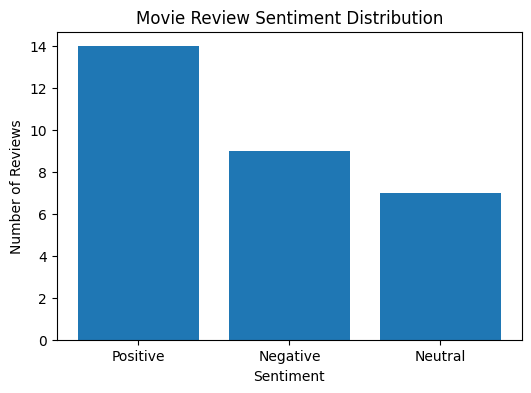

In [90]:
sentiment_count = data["Sentiment"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Movie Review Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()





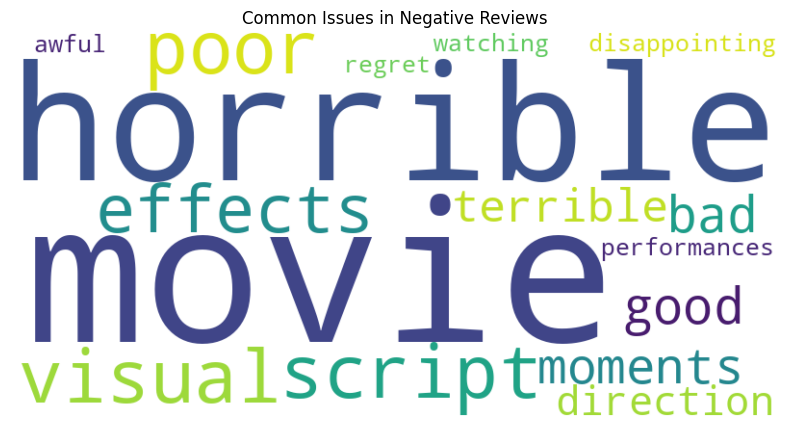

In [91]:
negative_text = " ".join(negative_reviews['Clean_Review'])

if len(negative_text) > 0:
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white').generate(negative_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Common Issues in Negative Reviews")
    plt.show()

